# **HANDS ON: INTRODUCCIÓN A ESTADÍSTICA DESCRIPTIVA**


Una vez visto la presentación ***Introducción a la estadística descriptiva***, se proporciona el siguiente ***colab*** para que **el alumnado pueda practicar** haciendo uso del lenguaje de programación ***python***.


## **ANÁLISIS UNIVARIABLE**

El **análisis univariable** es el análisis que se realiza a **una sola variable** a la vez. Su propósito principal es **describir la distribución, frecuencia y tendencia** de esa única característica, sin considerar relaciones de causa o efecto.

***NOTA:*** *Se hará el uso de las bibliotecas de **Pandas** y **Seaborn** para usar datasets precargados sin entrar a tanto detalle a las librerías mismas. Para ello, se explicará mas a detalle en el siguiente módulo.*

In [1]:
#Importar librerías
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Importar dataset
df_tips = sns.load_dataset('tips')
df_tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [8]:
# Mostrar propiedades de la tabla
df_tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [9]:
# Mostrar resumen estadístico
df_tips.describe()  #solo funciona en variables numéricas
#Seaborn dataset listing , ouput (sample)

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [ ]:
# Realizar una proporción de probabilidad
media = round(df_tips.describe()['total_bill']['mean'], 4)
#     redondear       Tabla         columna      fila , 4 = num que voy a redondear
print(f'La media es: {media}')

std = round(df_tips.describe()['total_bill']['std'], 4)
print(f'La desviación estándar es: {std}')

#La proporcion de probailidad
prop_prob = round((std /media)*100 , 1) # Es más comodo verlo en porcentaje
print(f'Los datos se separan de la media a un: {prop_prob}%')

La media es: 19.7859
La desviación estándar es: 8.9024
Los datos se separan de la media a un: 45.0%


#### **MEDIDAS DE TENDENCIA CENTRAL**

Las **medidas de tendencia central** (MTC) son métricas estadísticas que nos permiten **resumir un conjunto de datos en un solo valor**. Estas métricas nos indican cuál es el **valor que se encuentra en el centro** de un conjunto de datos.

Las medidas de tendencia central son:

*   **Media:** Es el valor promedio de un conjunto de datos y es muy sensible a los sesgos.

*   **Mediana:** Es el valor que se encuentra en el centro de un conjunto de datos ordenados y es menos sensible a los sesgos.

*   **Moda:** Es el valor que aparece con más frecuencia en un conjunto de datos.

In [3]:
# Definir variables
media = round(df_tips['total_bill'].mean(),2)  #una dataframe --> Tabla, cada tabla se compone por series --> Columnas, así que cada elemento de la serie es un value -->valor
#Los DataFrames DF y Las series tienen sus propios atributos y métodos
print(media)

mediana = round(df_tips['total_bill'].median(),2)
print(mediana)

moda = df_tips['total_bill'].mode().iloc[0] #Mode devuelve el valor que aparece mayor de veces, iloc = indice numerico, lo devuelve como valor numérico
print(moda)



19.79
17.8
13.42


In [11]:
# Definir listas

mtc_datos = [media, mediana, moda]
mtc_nombres = ['Media', 'Mediana', 'Moda']
mtc_colores = ['green', 'red', 'blue']

mtc_configuraciones = zip(mtc_nombres, mtc_datos, mtc_colores)
print(mtc_configuraciones)

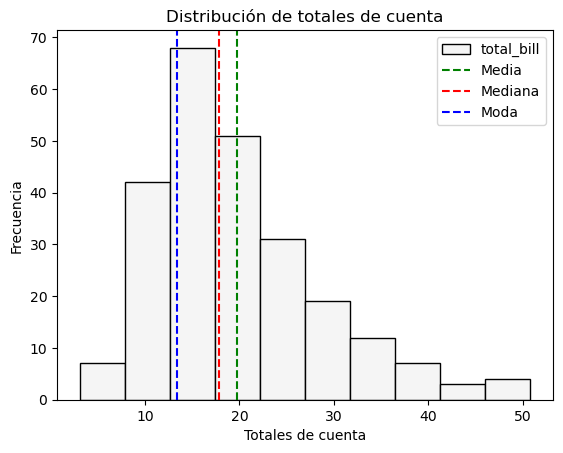

In [12]:
# Visualizar métricas de tendencia central
df_tips['total_bill'].plot(kind ='hist', color = 'whitesmoke', edgecolor= 'black')
plt.title('Distribución de totales de cuenta')
plt.xlabel('Totales de cuenta')
plt.ylabel('Frecuencia')

# Iterar sobre la lista de configuraciones para dibujar las líneas
for nombre, dato, color in mtc_configuraciones:
    plt.axvline(x=dato, color=color, linestyle='--', label=nombre)

plt.legend()
plt.show()

### **MEDIDAS DE DISPERSIÓN**

Las **medidas de dispersión** indican qué tan **extendidos o separados se encuentran los datos de una distribución** respecto a un valor central. Son fundamentales para determinar la **variabilidad y la confiabilidad** de un conjunto de datos.

Las métricas de disperción mas utilizadas son:

*   **Desviación estandar:** Es la media de las desviaciones de los datos, a mayor desviación los datos estarán más dispersos.

*   **Cuartíl:** Son los valores estadísticos que dividen una distribución en 4 partes iguales formando un **rango intercuartílico**.

#### **DESVIACIÓN ESTANDAR**

La **desviación estándar** es una medida de la dispersión de un conjunto de datos numéricos. Se calcula como la media de las desviaciones de los datos con respecto a la media.

Se interpreta como **la distancia promedio entre los datos y la media.** Una **desviación estándar baja** indica que los datos están agrupados cerca de la media, mientras que una **desviación estándar alta** indica que los datos están más dispersos.

In [13]:
# Definir variables
x = range(len(df_tips['total_bill']))
y = df_tips['total_bill']

print(x)
print(y)

std = np.std(df_tips['total_bill'])
print(std)
#Desviación estandar es cuando que esta tan alejado de datos con la información con respecto a la media. Se saca de calculo estadistico de la cantidad que tengo.
#pero dentro de un rango.
#que tan dispersos estan mis datos con respecto a la media, en este caso 8.8841

range(0, 244)
0      16.99
1      10.34
2      21.01
3      23.68
4      24.59
       ...  
239    29.03
240    27.18
241    22.67
242    17.82
243    18.78
Name: total_bill, Length: 244, dtype: float64
8.88415057777113


In [14]:
# Definir listas
std_datos = [media, media + std , media - std] #media, desciación estandar positiva, desviacíon estandar negativa
std_nombres = ['Media', 'Desviación estandar', None]
std_colores = ['green', 'blue', 'blue']

std_configuraciones = zip(std_nombres, std_datos, std_colores)


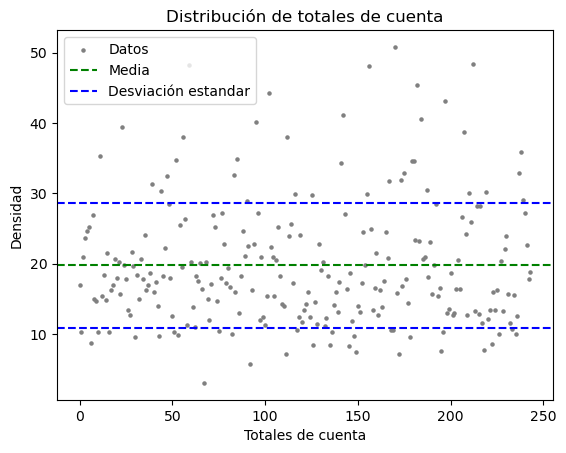

In [15]:
# Visualizar dipersión de los datos
plt.scatter(x, y, label = 'Datos', s= 5 , color= 'grey')
plt.title('Distribución de totales de cuenta')
plt.xlabel('Totales de cuenta')
plt.ylabel('Densidad')


for nombre, dato, color in std_configuraciones:
    plt.axhline(y=dato, color=color, linestyle = '--', label = nombre)

plt.legend()
plt.show()



#### **PERCENTILES**

Los **percentiles** son valores estadísticos que dividen una distribución de datos en **100 partes iguales** (por el cual puede ser asociado como porcentaje). Se utilizan comúnmente en estadísticas y análisis de datos para entender la posición de un valor específico en relación con otros valores en un conjunto de datos.

Los percentiles pueden ser trabajados por **cuartiles**, el cual es dividir en **4 partes iguales** la misma distribución, siendo cada parte una agrupación del 25% de elementos de la distribución. Su gráfico mas representativo es el **gráfico de caja** y forma un **rango intercuartílico** (IQR) cuando se realiza la diferencia entre el primer y tercer cuartil.

In [4]:
# Definir variables
percentil = np.percentile(df_tips['total_bill'],[25, 50, 75])
print(percentil)

q_1 = round(percentil[0],2)
q_3 = round(percentil[2],2)
print(q_1)
print(q_3)

iqr = q_3 - q_1
print(iqr)

[13.3475 17.795  24.1275]
13.35
24.13
10.78


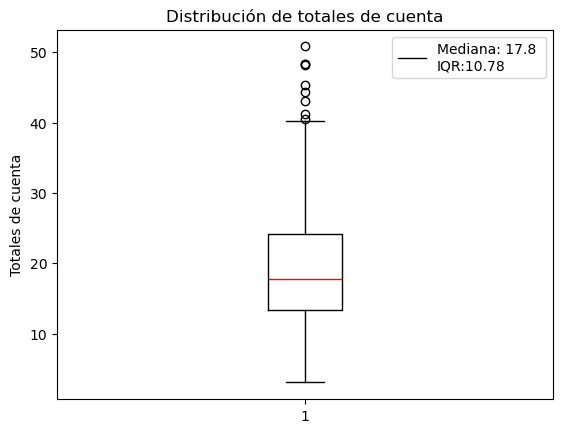

In [34]:
# Visualizar percentiles
plt.boxplot(df_tips['total_bill'], medianprops={'color': 'red'})
plt.title('Distribución de totales de cuenta')
plt.ylabel('Totales de cuenta')
plt.legend([f'Mediana: {mediana} \nIQR:{iqr}'])  #Escape de linea: \n(salto de línea),\t (tabulación), \\ , \'
plt.show()

#Es muy necesario estos graficos para saber si tengo un sesgo por la derecha, en este caso negativo, si quieres ver mayor detalle con el histograma,
#Por lo tanto se complementan bien una y otra

Text(0.5, 0, 'Totales de cuenta')

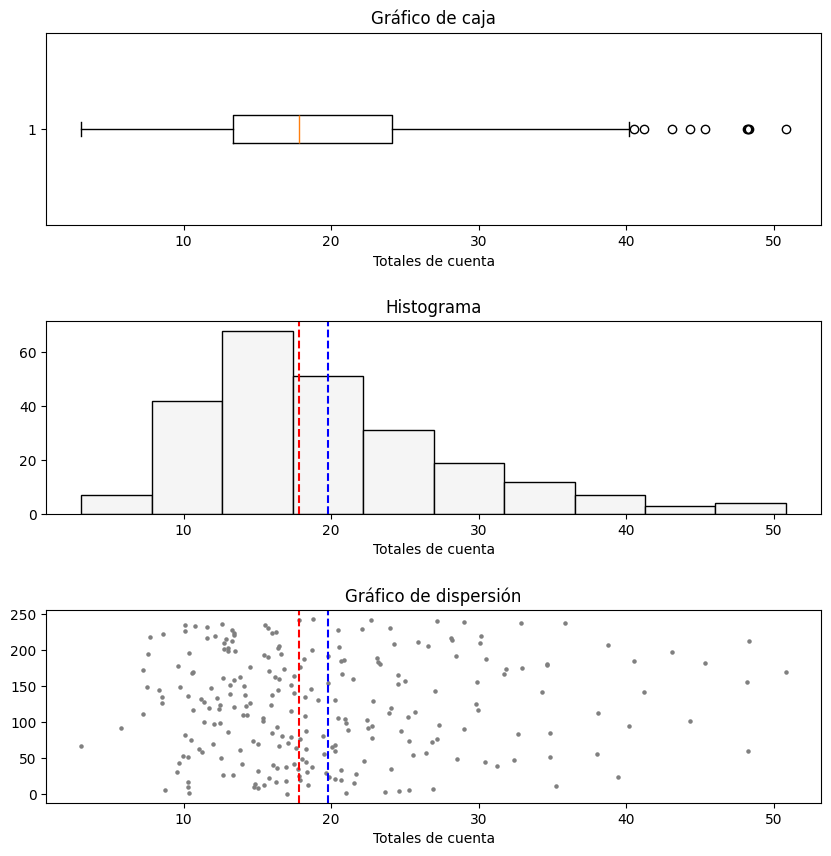

In [ ]:
# Asociar gráficos
fig, ax = plt.subplots(3, figsize=(10,10), gridspec_kw={'hspace':0.5})

ax[0].boxplot(df_tips['total_bill'], vert = False)
ax[0].set_title('Gráfico de caja')
ax[0].set_xlabel('Totales de cuenta')

ax[1].hist(df_tips['total_bill'], edgecolor = 'black', color='whitesmoke')
ax[1].axvline(x=mediana, linestyle = '--', color ='red')
ax[1].axvline(x=media, linestyle = '--', color ='blue')
ax[1].set_title('Histograma')
ax[1].set_xlabel('Totales de cuenta')

ax[2].scatter(y,x, s=5, color = 'grey')
ax[2].axvline(x=mediana, linestyle = '--', color ='red')
ax[2].axvline(x=media, linestyle = '--', color ='blue')
ax[2].set_title('Gráfico de dispersión')
ax[2].set_xlabel('Totales de cuenta')


## **ANÁLISIS BIVARIABLE**

El **análisis bivariable** consiste en el estudio de la **relación entre dos variables** simultáneamente. Se utiliza para **determinar si existe una asociación, correlación o dependencia** entre ellas.

### **CORRELACIÓN**

La **correlación** es una medida estadística que **cuantifica la fuerza y la dirección de la relación** o asociación **entre dos o más variables**, describiendo de esa manera cómo el **cambio en una variable se asocia con el cambio en otra**.

**La correlación no implica causalidad**. Que dos variables cambien juntas **no significa necesariamente que una sea la causa de la otra**; ambos cambios podrían deberse a un tercer factor desconocido.

#### **MULTIVARIABLE**

Analiza la **interacción y los patrones entre tres o más variables** simultáneamente. Busca entender cómo múltiples factores influyen en un resultado o se agrupan entre sí.

Las **matrices de correlación** muestran los **coeficientes de correlación bivariados** para todos los pares posibles en un conjunto de datos grande.

In [35]:
# Definir variables
columnas = ['total_bill', 'tip', 'size']
corr = df_tips[columnas].corr()
long_col =len(columnas)
print(corr)

            total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


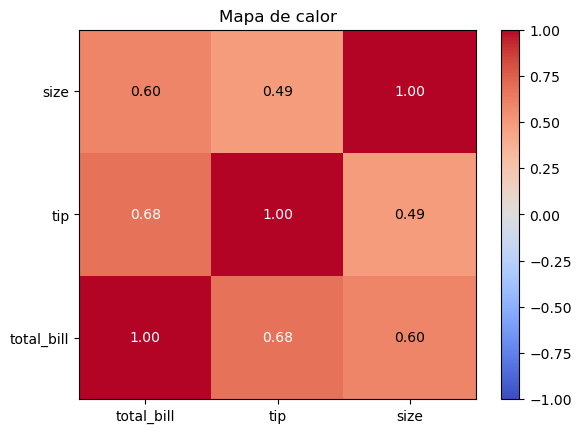

In [36]:
# Visualizar mapa de calor
heatmap = plt.pcolor(corr, cmap = 'coolwarm', vmin= -1, vmax= 1)
plt.title('Mapa de calor')

plt.xticks(np.arange(0.5, long_col,1), columnas)
plt.yticks(np.arange(0.5, long_col,1), columnas)

for i in range(len(columnas)):
  for j in range(len(columnas)):
    #plt.text(j, i, f'{round(corr.iloc[i,j], 2)}')
    # con : indica que lo voy aplicar formato
     plt.text(j + 0.5, i + 0.5, f'{corr.iloc[i,j]:.2f}',
              ha= 'center', va= 'center',
              color= 'white' if abs(corr.iloc[i,j])>0.6 else 'black')

plt.colorbar()
plt.show()
#Notas:
#Que tanta relación tiene un dato con los demás datos
#No hacer caso al 1
#Correlación: que tanto se comportan igual mis datos

#### **BIVARIABLE**

Examina la **relación entre dos variables aleatorias**. Su objetivo es determinar si existe una **asociación, dirección (positiva o negativa) y fuerza**. Algunas herramientas comunes son:

*   **Coeficiente de Pearson:** Mide la fuerza de una relación lineal entre variables cuantitativas.

*   **Diagramas de dispersión:** Gráficos de "nube de puntos" que permiten visualizar la tendencia entre las dos variables.

In [37]:
# Definir variables
corr_cuenta_propina = round( df_tips['total_bill'].corr(df_tips['tip']),2)
print(corr_cuenta_propina)

corr_mesa_cuenta = round(df_tips['size'].corr(df_tips['total_bill']),2)
print(corr_mesa_cuenta)

corr_mesa_propina = round(df_tips['size'].corr(df_tips['tip']),2)
print(corr_mesa_propina)

0.68
0.6
0.49


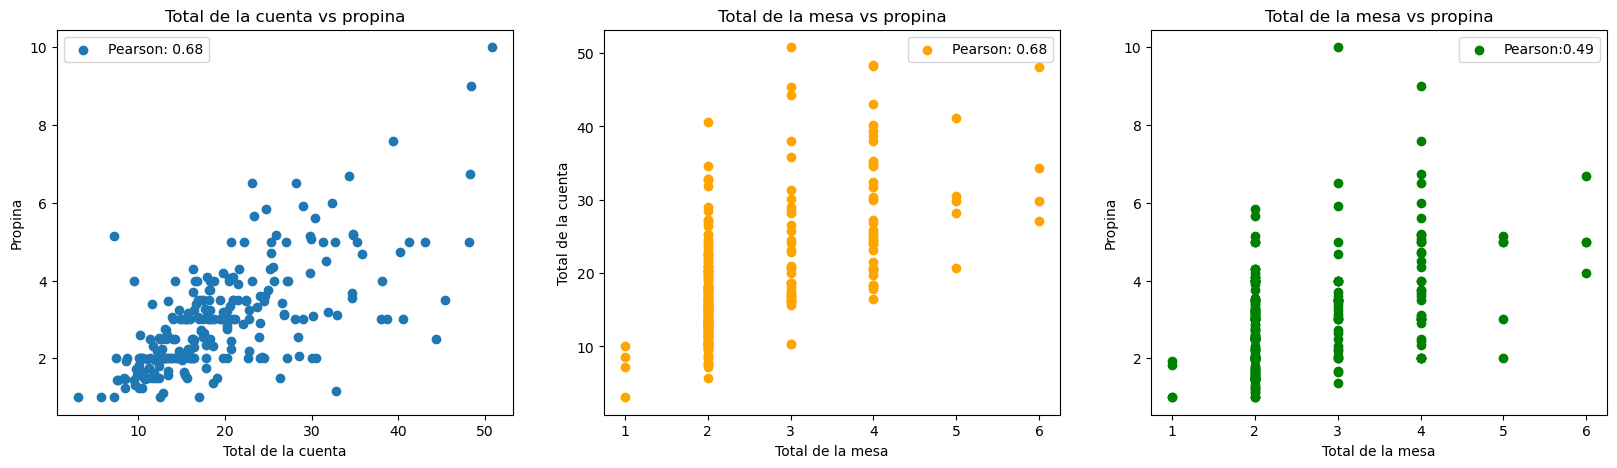

In [38]:
# Visualizar correlaciones

fig, ax = plt.subplots(1,3, figsize = (20,5))

ax[0].scatter(data=df_tips, x='total_bill', y='tip', label = f'Pearson: {corr_cuenta_propina}')
ax[0].set_title('Total de la cuenta vs propina')
ax[0].set_xlabel('Total de la cuenta')
ax[0].set_ylabel('Propina')
ax[0].legend()

ax[1].scatter(data=df_tips, x='size', y='total_bill', label = f'Pearson: {corr_cuenta_propina}', color='orange')
ax[1].set_title('Total de la mesa vs propina')
ax[1].set_xlabel('Total de la mesa')
ax[1].set_ylabel('Total de la cuenta')
ax[1].legend()

ax[2].scatter(data=df_tips, x='size', y='tip', label = f'Pearson:{corr_mesa_propina}', color='green')
ax[2].set_title('Total de la mesa vs propina')
ax[2].set_xlabel('Total de la mesa')
ax[2].set_ylabel('Propina')
ax[2].legend()

## **CHALLENGE: ANÁLISIS DESCRIPTIVO DE DATOS**

Una vez visto el ***Hands - On: Introducción a la estadística descriptiva***, se presentan las siguientes actividades para que el alumnado pueda repasar y reforzar lo aprendido dentro de la clase.

Dentro de la siguiente dinámica, **se realizará un análisis de estadística descriptiva** haciendo uso de **operaciones vectorizadas y visualización de datos** a través del **dataset taxis** proveniente de la librería de ***Seaborn***.

Donde los análisis a realizar son:

*   **Análisis univariable**
*   **Análisis bivariable**

**IMPORTANTE:** Para su revisión, **es indispensable que los apartados anteriores se encuentren llenados con el código visto durante la sesión.**

### **INSTRUCCIONES:**

**1. Importa las librerías:** Carga las bibliotecas de Numpy, Pandas, Seaborn y Matplotlib.pyplot.










In [39]:
# Importar librerías
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

**2. Importa el dataset de taxis:** Crea una variable denominada df_taxis donde se importe el dataset taxis.

In [41]:
# Import dataset
df_taxis = sns.load_dataset('taxis')
df_taxis

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


**3. Muestra los datos generales del dataset:**

   * Muestra las propiedades del dataset.
   * Muestra el resumen estadístico del dataset.

In [42]:
# Mostrar propiedades de la tabla
df_taxis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

In [43]:
# Mostrar resumen estadístico
df_taxis.describe()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223616,2019-03-16 08:45:49.491217408,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570


**4. Realiza un análisis de univariable:**

   * Cálcula las medidas de tendencia central de la columna total.
   * Cálcula las medidas de dispersión de la columna total.
   * Visualiza los gráficos de las medidas obtenidas en un subplot de 3 columnas.

In [49]:
# Definir medidas de tendencia central
media = round(df_taxis['total'].mean(), 2)
mediana = round(df_taxis['total'].median(), 2)
moda = df_taxis['total'].mode().iloc[0]

print(f'Media: {media}')
print(f'Mediana: {mediana}')
print(f'Moda: {moda}')

Media: 18.52
Mediana: 14.16
Moda: 9.3


In [50]:
# Definir medidas de dispersión
x = range(len(df_taxis['total']))
y= df_taxis['total']

print(x)
print(y)

std = np.std(df_taxis['total'])
print(std)

range(0, 6433)
0       12.95
1        9.30
2       14.16
3       36.95
4       13.40
        ...  
6428     6.36
6429    58.80
6430    17.30
6431     6.80
6432    20.16
Name: total, Length: 6433, dtype: float64
13.814496194728799


In [ ]:
# Definir variables
percentil = np.percentile(df_taxis['total'],[25, 50, 75])
print(percentil)

q_1 = round(percentil[0],2)
q_3 = round(percentil[2],2)
print(q_1)
print(q_3)

iqr = q_3 - q_1
print(iqr)

[10.8  14.16 20.3 ]
10.8
20.3
9.5


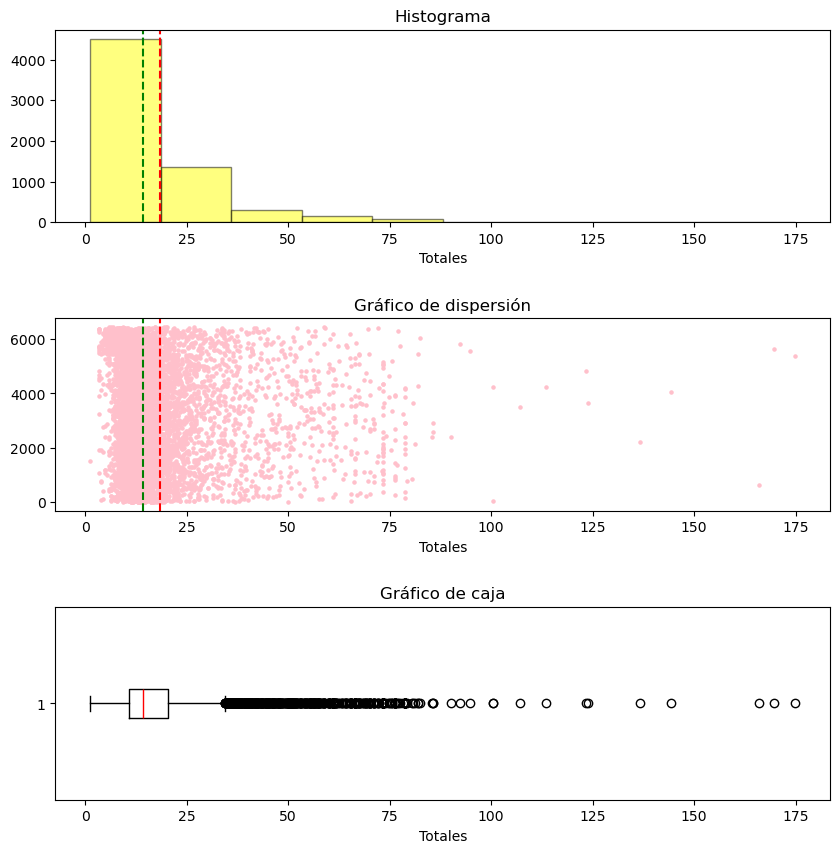

In [65]:
# Visualizar medidas descriptivas
fig, ax = plt.subplots(3, figsize= (10,10), gridspec_kw= {'hspace': 0.5})

ax[0].hist(df_taxis['total'], edgecolor = 'black', color = 'yellow', alpha = 0.5)
ax[0].set_title('Histograma')
ax[0].axvline(x=mediana, color='green', linestyle='--' )
ax[0].axvline(x=media, color='red', linestyle='--')
ax[0].set_xlabel('Totales')


ax[1].scatter(y, x, s= 5, color = 'pink')
ax[1].axvline(x=mediana, color='green', linestyle='--' )
ax[1].axvline(x=media, color='red', linestyle='--')
ax[1].set_title('Gráfico de dispersión')
ax[1].set_xlabel('Totales')


ax[2].boxplot(df_taxis['total'], vert= False, medianprops= {'color': 'red'})
ax[2].set_title('Gráfico de caja')
ax[2].set_xlabel('Totales')

plt.show()

**5. Realiza un análisis de multivariable:** Visualiza en un mapa de calor los coeficientes de correlación para todos los pares posibles de las columnas numéricas del dataset.

In [71]:
# Definir variables
columnas = ['total', 'tip', 'fare', 'distance' ]
corr = df_taxis[columnas].corr()
long_col= len(columnas)
print(corr)

             total       tip      fare  distance
total     1.000000  0.646186  0.974358  0.904676
tip       0.646186  1.000000  0.488612  0.452589
fare      0.974358  0.488612  1.000000  0.920108
distance  0.904676  0.452589  0.920108  1.000000


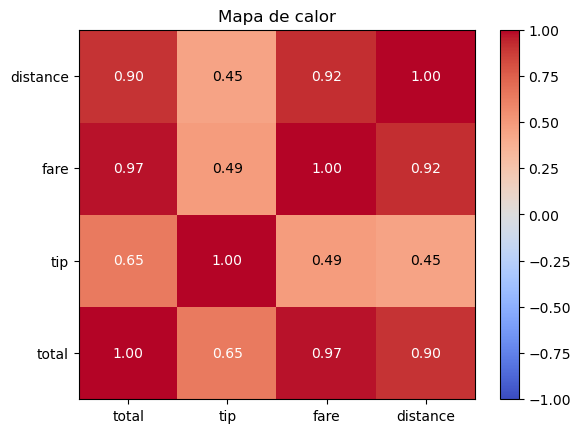

In [72]:
# Visualizar mapa de calor

heatmap = plt.pcolor(corr, cmap = 'coolwarm', vmin = -1, vmax= 1)
plt.title('Mapa de calor')

plt.xticks(np.arange(0.5, long_col, 1), columnas)
plt.yticks(np.arange(0.5, long_col, 1), columnas)

for i in range(len(columnas)):
    for j in range(len(columnas)):
        plt.text(j + 0.5, i + 0.5, f'{corr.iloc[i,j]:.2f}', 
                 ha = 'center', va= 'center',
                 color= 'white' if abs(corr.iloc[i,j])>0.6 else 'black')
plt.colorbar()
plt.show()

 **6. Realiza un análisis de bivariable:**

   * Cálcula los coeficientes de correlación de pearson de las 3 correlaciones mas fuertes obtenidas en el gráfico de calor.
   * Visualiza los gráficos de las correlaciones obtenidas en un subplot de 3 columnas.

In [76]:
# Definir variables
corr_total = round(df_taxis['fare'].corr(df_taxis['total']), 2)
corr_fare= round(df_taxis['distance'].corr(df_taxis['fare']), 2)
corr_distance = round(df_taxis['distance'].corr(df_taxis['total']), 2)

print(f'Correlación entre tarifa y total: {corr_total}')
print(f'Correlación entre distancia y tarifa: {corr_fare}')
print(f'Correlación entre distancia y total: {corr_distance}')


Correlación entre tarifa y total: 0.97
Correlación entre distancia y tarifa: 0.92
Correlación entre distancia y total: 0.9


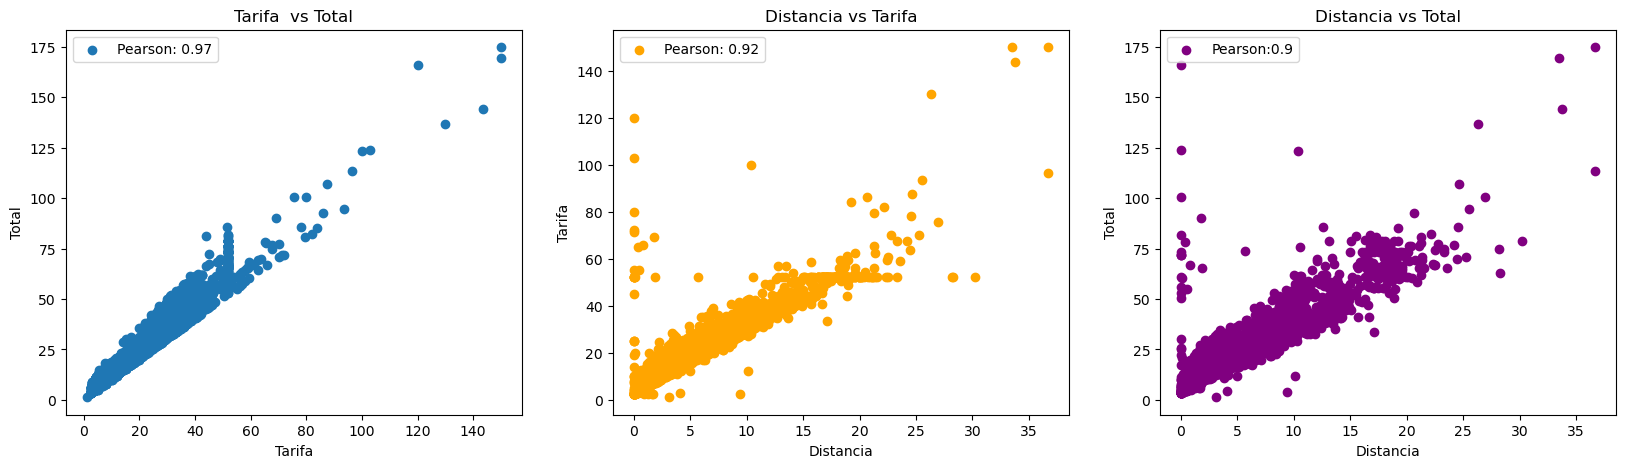

In [77]:
# Visualizar correlaciones
fig, ax = plt.subplots(1,3, figsize = (20,5))

ax[0].scatter(data=df_taxis, x='fare', y='total', label = f'Pearson: {corr_total}')
ax[0].set_title('Tarifa  vs Total')
ax[0].set_xlabel('Tarifa')
ax[0].set_ylabel('Total')
ax[0].legend()

ax[1].scatter(data=df_taxis, x='distance', y='fare', label = f'Pearson: {corr_fare}', color='orange')
ax[1].set_title('Distancia vs Tarifa')
ax[1].set_xlabel('Distancia')
ax[1].set_ylabel('Tarifa')
ax[1].legend()

ax[2].scatter(data=df_taxis, x='distance', y='total', label = f'Pearson:{corr_distance}', color='purple')
ax[2].set_title('Distancia vs Total')
ax[2].set_xlabel('Distancia')
ax[2].set_ylabel('Total')
ax[2].legend()

plt.show()